# 13. Context Windows & KV Cache

**Tier:** Building with LLMs
**Estimated time:** 50 minutes
**Prerequisites:** 02, 04, 12
**Priority:** 🔴 Crucial — context budgeting/caching costs affect every production feature (ties to 32). *If skipped, revisit when:* n/a.
**Source material:** Stanford LLM curriculum, Lecture 3 (LLMs & inference optimization) — https://x.com/ajitcodes/status/2057043965317165490 ; @sairahul1 — https://x.com/sairahul1/status/2057740928908161461

## What You'll Learn
- Why the context window is a hard ceiling, and what fills it up besides your prompt
- Why attention (notebook 04) gets expensive as the sequence grows, and how the KV cache avoids redoing that work every token
- How Anthropic prompt caching turns a repeated prefix into a near-free re-read

## Why This Matters
Every notebook from here on (RAG, agents, multi-turn loops) is bounded by the context window and paid for in tokens. Understanding what's actually inside that window — and what's cheap to keep there versus expensive to regenerate — is the difference between a system that scales and one that falls over at turn 20.


## The context window is a shared, shrinking budget

The context window is the maximum number of tokens (notebook 02) the model can attend over in one call — system prompt + conversation history + retrieved documents + the model's own output, all sharing the same budget. Picture a desk with a fixed amount of space: every document you put on it (system rules, chat history, a retrieved PDF chunk) takes up room the model could otherwise spend thinking about your actual question. Once the desk is full, *something* gets pushed off — usually the oldest turns, silently.

This matters more once a notebook 04 transformer is involved, because self-attention compares every token to every other token: a sequence of length *n* costs roughly *n²* attention operations. Doubling your context window doesn't just need more memory — the compute for attention roughly **quadruples**. That's why long contexts are not "free" even when the model nominally supports them.

The other cost is **redundant work across turns**. In a 50-turn conversation, naively re-running the model from scratch each turn means recomputing attention for the first 49 turns' tokens *again, every single time* — even though nothing about them changed. That redundancy is exactly what the KV cache below is designed to eliminate.


In [1]:
import os
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"

def ask(prompt, system="You are a helpful assistant.", max_tokens=200, model=TEACH_MODEL, extra_headers=None):
    if not HAS_ANTHROPIC:
        print("  [skipped: no ANTHROPIC_API_KEY]")
        return None
    try:
        import anthropic
        client = anthropic.Anthropic()
        kwargs = dict(model=model, max_tokens=max_tokens, system=system,
                      messages=[{"role": "user", "content": prompt}])
        if extra_headers:
            kwargs["extra_headers"] = extra_headers
        msg = client.messages.create(**kwargs)
        return msg
    except Exception as e:
        print(f"  [skipped: API call failed — {type(e).__name__}: {str(e)[:150]}]")
        return None


## Minimal example: token growth and the quadratic cost of attention

We use the GPT-2 tokenizer from notebook 02 to count tokens, then measure how many scaled dot-product comparisons (notebook 04) a sequence of that length requires.


In [2]:
try:
    from transformers import GPT2TokenizerFast
    tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
    HAS_TOKENIZER = True
except Exception as e:
    HAS_TOKENIZER = False
    print(f"Could not load GPT-2 tokenizer (offline?): {e}")

sample_turns = [
    "You are a helpful assistant for Helios Robotics customers.",
    "User: How do I reset my X1's wifi module?",
    "Assistant: Hold the reset button for 10 seconds while powered on, then release.",
    "User: That didn't work, the LED stayed red.",
    "Assistant: A solid red LED after reset usually means a firmware mismatch — check the app for a pending update.",
]

if HAS_TOKENIZER:
    cumulative_text = ""
    token_counts = []
    for turn in sample_turns:
        cumulative_text += " " + turn
        n_tokens = len(tokenizer.encode(cumulative_text))
        token_counts.append(n_tokens)
        print(f"After {len(token_counts)} turn(s): {n_tokens} tokens, "
              f"~{n_tokens**2:,} attention score entries (n^2)")


After 1 turn(s): 11 tokens, ~121 attention score entries (n^2)
After 2 turn(s): 24 tokens, ~576 attention score entries (n^2)
After 3 turn(s): 40 tokens, ~1,600 attention score entries (n^2)
After 4 turn(s): 52 tokens, ~2,704 attention score entries (n^2)
After 5 turn(s): 74 tokens, ~5,476 attention score entries (n^2)


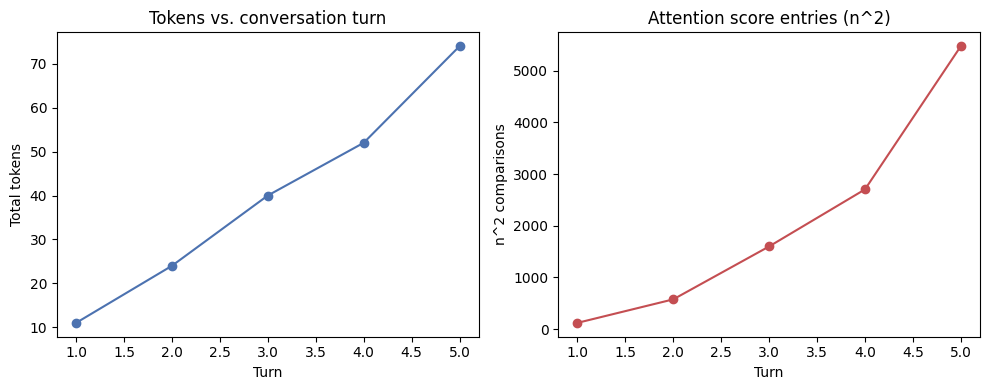

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

if HAS_TOKENIZER:
    attention_ops = [n**2 for n in token_counts]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(range(1, len(token_counts) + 1), token_counts, marker="o", color="#4C72B0")
    ax1.set_title("Tokens vs. conversation turn"); ax1.set_xlabel("Turn"); ax1.set_ylabel("Total tokens")
    ax2.plot(range(1, len(attention_ops) + 1), attention_ops, marker="o", color="#C44E52")
    ax2.set_title("Attention score entries (n^2)"); ax2.set_xlabel("Turn"); ax2.set_ylabel("n^2 comparisons")
    plt.tight_layout(); plt.show()


*Tokens grow linearly with each turn, but the number of attention comparisons grows quadratically — a 2x longer conversation is roughly 4x more attention work per forward pass, before caching.*


## The KV cache: stop recomputing what hasn't changed

Inside attention, every token produces a **Key** and a **Value** vector (the K and V in notebook 04's `Attention(Q, K, V)`). For tokens already generated, those K/V vectors never change — only a *new* token needs a freshly computed Query compared against everyone else's *already-computed* Keys and Values. The KV cache is simply storing those K/V vectors instead of recomputing them: generation becomes "compute K/V for the one new token, reuse everything else," turning the per-token cost from *O(n)* new work back down to *O(1)* per step (plus an *O(n)* memory cost to hold the cache).

We simulate this with toy vectors below — no real model needed to see the shape of the savings.


In [ ]:
import numpy as np
import time

def attention_no_cache(seq_len, d=64):
    """Recompute K and V for the WHOLE sequence at every new token (the naive way)."""
    rng = np.random.default_rng(0)
    total_ops = 0
    for t in range(1, seq_len + 1):
        K = rng.standard_normal((t, d))   # recomputed from scratch every step
        V = rng.standard_normal((t, d))
        q = rng.standard_normal((1, d))
        scores = q @ K.T
        total_ops += t * d   # work proportional to recomputing all of K (and V)
    return total_ops

def attention_with_cache(seq_len, d=64):
    """Compute K/V once per NEW token only, reuse the cache for everything before it."""
    rng = np.random.default_rng(0)
    total_ops = 0
    cached_K, cached_V = [], []
    for t in range(1, seq_len + 1):
        new_k = rng.standard_normal((1, d))   # only this token's K/V is new work
        new_v = rng.standard_normal((1, d))
        cached_K.append(new_k); cached_V.append(new_v)
        total_ops += d   # only the new token's K/V computation
    return total_ops

for seq_len in [10, 50, 100, 200]:
    no_cache = attention_no_cache(seq_len)
    with_cache = attention_with_cache(seq_len)
    print(f"seq_len={seq_len:4d}  no-cache ops={no_cache:8,d}  "
          f"with-cache ops={with_cache:6,d}  speedup={no_cache/with_cache:6.1f}x")


## Prompt caching: the same idea, applied to your prompt prefix

Anthropic's prompt caching extends the same principle to the *system prompt and any long, repeated prefix*: if the first part of your request is byte-identical to a previous call, the API can reuse its internal K/V computation for that prefix instead of reprocessing it, billed at a fraction of the normal input-token rate. This is the lead-in to notebook 16's 92% cache-hit-rate example — here we just confirm caching is wired up correctly with a long, repeated system prompt.


In [ ]:
LONG_SYSTEM_PROMPT = (
    "You are a Helios Robotics support assistant. " * 80
)  # long + repeated on purpose, to be eligible for caching

msg = ask(
    "In one sentence, what is your role?",
    system=LONG_SYSTEM_PROMPT,
    max_tokens=30,
)
if msg is not None:
    print(msg.content[0].text)
    usage = msg.usage
    print(f"\ninput_tokens={usage.input_tokens}  "
          f"cache_creation_input_tokens={getattr(usage, 'cache_creation_input_tokens', 'n/a')}  "
          f"cache_read_input_tokens={getattr(usage, 'cache_read_input_tokens', 'n/a')}")
    print("(cache_read_input_tokens > 0 on a second identical call means the cache hit.)")


## Exercises


In [ ]:
# Exercise 1 (Warm-up): Watch the quadratic curve bend
# Task: Re-run the token-growth cell with sample_turns extended to 15 turns (repeat the
#       pattern). Plot tokens vs n^2 again — does the gap between the two curves widen?
# Hint: Just append more strings to sample_turns before re-running the tokenizer loop.

# YOUR CODE HERE


In [ ]:
# Exercise 2 (Apply): Implement a real KV-cache simulation
# Task: Modify attention_with_cache so it actually STORES cached_K/cached_V across calls
#       (not just within one call) and reuses them if seq_len from the previous call is a
#       prefix of the new one. Time both approaches with Python's `time` module.
# Hint: Use a module-level dict keyed by a tuple of the first N tokens (or just track the
#       cache length) to decide how much of the old K/V you can reuse.

# YOUR CODE HERE


In [ ]:
# Exercise 3 (Extend): Call the cache cell twice
# Task: Run the LONG_SYSTEM_PROMPT cell twice in a row (same exact system string) and compare
#       cache_read_input_tokens between the two calls. What do you expect to change?
# Hint: The first call creates the cache (cache_creation_input_tokens > 0); a second call with
#       the IDENTICAL prefix should show cache_read_input_tokens > 0 instead. This is exactly
#       the mechanism notebook 16 measures at scale.

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
sample_turns_long = sample_turns + [
    "User: Could you send me the firmware download link?",
    "Assistant: Sure — it's under Settings > Updates in the companion app.",
    "User: Found it, thanks. One more thing about the battery.",
    "Assistant: Go ahead.",
    "User: Is it normal for it to get warm while charging?",
    "Assistant: Mild warmth is normal; if it's hot to the touch, stop charging and contact support.",
    "User: Good to know.",
    "Assistant: Anything else I can help with?",
    "User: That covers it, thanks!",
    "Assistant: You're welcome — have a great day!",
]
cum = ""
counts = []
for turn in sample_turns_long:
    cum += " " + turn
    counts.append(len(tokenizer.encode(cum)))
print(counts, [c**2 for c in counts])
# The n^2 curve visibly outpaces the linear token curve as more turns are added.

# Exercise 2
_kv_cache_store = {}
def attention_with_persistent_cache(seq_len, d=64, cache_key="conv1"):
    rng = np.random.default_rng(0)
    cached = _kv_cache_store.get(cache_key, [])
    new_tokens_needed = seq_len - len(cached)
    for _ in range(max(new_tokens_needed, 0)):
        cached.append(rng.standard_normal(d))
    _kv_cache_store[cache_key] = cached
    return new_tokens_needed * d   # only newly-added tokens cost work

import time
t0 = time.perf_counter(); attention_with_persistent_cache(100); t1 = time.perf_counter()
attention_with_persistent_cache(105)  # only 5 new tokens of work this time
t2 = time.perf_counter()
print(f"first call: {t1-t0:.6f}s, incremental call: {t2-t1:.6f}s")

# Exercise 3
msg1 = ask("What is your role?", system=LONG_SYSTEM_PROMPT, max_tokens=20)
msg2 = ask("What is your role, briefly?", system=LONG_SYSTEM_PROMPT, max_tokens=20)
for i, m in enumerate([msg1, msg2], 1):
    if m is not None:
        print(i, m.usage.cache_creation_input_tokens, m.usage.cache_read_input_tokens)
# Expect call 1: cache_creation_input_tokens > 0, cache_read_input_tokens == 0.
# Expect call 2: cache_creation_input_tokens == 0, cache_read_input_tokens > 0 (the hit).
```
</details>


## Key Takeaways
- The context window is a single shared budget for system prompt, history, retrieved text, and output — and it's a hard ceiling, not a soft suggestion.
- Self-attention cost grows roughly with the *square* of sequence length; doubling context isn't twice the compute, it's closer to four times.
- The KV cache avoids recomputing Key/Value vectors for tokens that haven't changed, turning per-token generation cost from growing with sequence length back down to roughly constant.
- Anthropic prompt caching applies the same idea to your prompt's repeated prefix (e.g. a long system message), billing a cache hit far below a normal input token.
- This is the mechanism behind notebook 16's "cold vs. hot" data split and its 92% cache-hit-rate example.

## What's Next
Notebook **14 — RAG Fundamentals** puts a concrete document into that context window — a company handbook the model was never trained on — and walks through chunking, embedding, retrieving, and generating an answer grounded in it.
